# Preprocessing dataset

###Dataset puskesmas

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy as sp

In [2]:
# upload dataset
from google.colab import files
uploaded = files.upload()

Saving dataset puskesmas.xlsx to dataset puskesmas.xlsx


In [3]:
# read dataset
covid = pd.read_excel('dataset puskesmas.xlsx')
print(covid)

      NO             KECAMATAN          PUSKESMAS  KASUS KONFIRMASI  SEMBUH  \
0    1.0              CILEUNYI      1    CILEUNYI               462     462   
1    2.0              CILEUNYI       2    CINUNUK              1039    1037   
2    3.0              CILEUNYI  3    CIBIRU HILIR               471     471   
3    4.0              CIMENYAN      4    CIMENYAN               550     549   
4    5.0              CIMENYAN    5    CIBEUNYING              1308    1307   
..   ...                   ...                ...               ...     ...   
58  59.0               CIWIDEY       59   CIWIDEY               106     106   
59  60.0               CIWIDEY      60   RAWABOGO               111     109   
60  61.0             RANCABALI     61   RANCABALI                80      80   
61  62.0             CANGKUANG        62   NAGRAK               497     497   
62   NaN  JUMLAH (KAB. BANDUNG                NaN             24856   24829   

    MENINGGAL  ANGKA\nKESEMBUHAN (RR) ANGKA KEMATIA

#### Filter status covid

In [4]:
# filter status covid Rendah
covid_filtered = covid[covid['STATUS COVID'] == "RENDAH"]
print(covid_filtered)

      NO      KECAMATAN             PUSKESMAS  KASUS KONFIRMASI  SEMBUH  \
0    1.0       CILEUNYI         1    CILEUNYI               462     462   
2    3.0       CILEUNYI     3    CIBIRU HILIR               471     471   
11  12.0       KATAPANG         12   KATAPANG               416     416   
12  13.0       KATAPANG      13   SANKANHURIP               488     488   
13  14.0    DAYEUHKOLOT      14   DAYEUHKOLOT               392     392   
15  16.0       BANJARAN    16   BANJARAN KOTA               286     286   
16  17.0       BANJARAN        17   KIANGROKE               436     436   
17  18.0    PAMEUNGPEUK      18   PAMEUNGPEUK               414     414   
18  19.0    PANGALENGAN  19   PANGALENGAN DTP               268     268   
19  20.0    PANGALENGAN        20   WARNASARI                83      83   
20  21.0    PANGALENGAN        21   SUKAMANAH               164     164   
21  22.0       ARJASARI         22   ARJASARI                70      70   
22  23.0       ARJASARI  

In [5]:
# filter status covid Sedang
covid_filtered = covid[covid['STATUS COVID'] == "SEDANG"]
print(covid_filtered)

      NO    KECAMATAN           PUSKESMAS  KASUS KONFIRMASI  SEMBUH  \
3    4.0     CIMENYAN       4    CIMENYAN               550     549   
5    6.0  CILENGKRANG    6    CILENGKRANG               656     656   
9   10.0    MARGAASIH      10   MARGAASIH               610     610   
14  15.0  DAYEUHKOLOT      15   CANGKUANG               739     739   
30  31.0    RANCAEKEK  31   RANCAEKEK DTP               700     698   
40  41.0   BALE ENDAH      41   BALEENDAH               787     784   
41  42.0   BALE ENDAH     42   RANCAMAYAR               622     620   
52  53.0      SOREANG        53   SOREANG               605     605   

    MENINGGAL  ANGKA\nKESEMBUHAN (RR) ANGKA KEMATIAN\n(CFR) STATUS COVID  
3           1                   99.82                  0.18       SEDANG  
5           0                  100.00                     -       SEDANG  
9           0                  100.00                     -       SEDANG  
14          0                  100.00                     - 

In [6]:
# filter status covid Tinggi
covid_filtered = covid[covid['STATUS COVID'] == "TINGGI"]
print(covid_filtered)

      NO    KECAMATAN               PUSKESMAS  KASUS KONFIRMASI  SEMBUH  \
1    2.0     CILEUNYI            2    CINUNUK              1039    1037   
4    5.0     CIMENYAN         5    CIBEUNYING              1308    1307   
6    7.0  BOJONGSOANG        7    BOJONGSOANG              1565    1564   
7    8.0    MARGAHAYU             8    BIHBUL              1723    1720   
8    9.0    MARGAHAYU  9    MARGAHAYU SELATAN               943     943   
10  11.0    MARGAASIH             11   RAHAYU              1460    1459   
42  43.0   BALE ENDAH           43   JELEKONG              1104    1104   

    MENINGGAL  ANGKA\nKESEMBUHAN (RR) ANGKA KEMATIAN\n(CFR) STATUS COVID  
1           2                   99.81                  0.19       TINGGI  
4           1                   99.92                  0.08       TINGGI  
6           1                   99.94                  0.06       TINGGI  
7           3                   99.83                  0.17       TINGGI  
8           0           

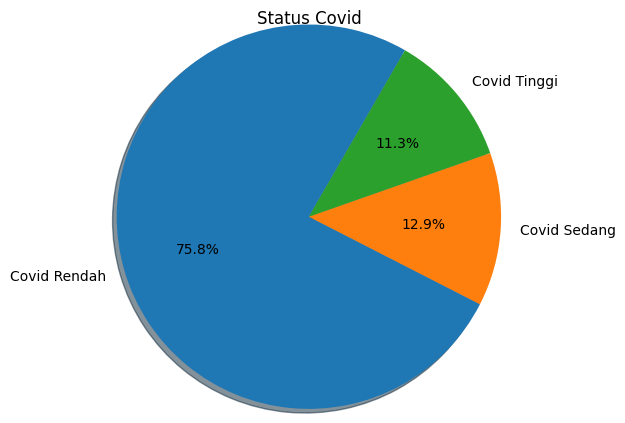

In [7]:
# Comparison plot status sovid Tinggi dan Rendah
covidOrno = [np.count_nonzero(covid['STATUS COVID'] == 'RENDAH'), np.count_nonzero(covid['STATUS COVID'] == 'SEDANG'), np.count_nonzero(covid['STATUS COVID'] == 'TINGGI')]
label = ['Covid Rendah', 'Covid Sedang', 'Covid Tinggi']
plt.title('Status Covid')
plt.pie(covidOrno, labels = label, radius=1.3, startangle=60, autopct='%.1f%%', shadow=True)
plt.show()

#### Handling missing values

In [8]:
# mengecek missing values
covid.isna().sum()

NO                        1
KECAMATAN                 0
PUSKESMAS                 1
KASUS KONFIRMASI          0
SEMBUH                    0
MENINGGAL                 0
ANGKA\nKESEMBUHAN (RR)    0
ANGKA KEMATIAN\n(CFR)     0
STATUS COVID              0
dtype: int64

In [9]:
# mengisi missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='constant', missing_values=np.nan, fill_value='-')
imputer = imputer.fit(covid[['NO','PUSKESMAS']])
covid[['NO','PUSKESMAS']] = imputer.transform(covid[['NO','PUSKESMAS']])
covid.isna().sum()

NO                        0
KECAMATAN                 0
PUSKESMAS                 0
KASUS KONFIRMASI          0
SEMBUH                    0
MENINGGAL                 0
ANGKA\nKESEMBUHAN (RR)    0
ANGKA KEMATIAN\n(CFR)     0
STATUS COVID              0
dtype: int64

In [10]:
print(covid)

      NO             KECAMATAN          PUSKESMAS  KASUS KONFIRMASI  SEMBUH  \
0    1.0              CILEUNYI      1    CILEUNYI               462     462   
1    2.0              CILEUNYI       2    CINUNUK              1039    1037   
2    3.0              CILEUNYI  3    CIBIRU HILIR               471     471   
3    4.0              CIMENYAN      4    CIMENYAN               550     549   
4    5.0              CIMENYAN    5    CIBEUNYING              1308    1307   
..   ...                   ...                ...               ...     ...   
58  59.0               CIWIDEY       59   CIWIDEY               106     106   
59  60.0               CIWIDEY      60   RAWABOGO               111     109   
60  61.0             RANCABALI     61   RANCABALI                80      80   
61  62.0             CANGKUANG        62   NAGRAK               497     497   
62     -  JUMLAH (KAB. BANDUNG                  -             24856   24829   

    MENINGGAL  ANGKA\nKESEMBUHAN (RR) ANGKA KEMATIA

In [11]:
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   NO                     63 non-null     object 
 1   KECAMATAN              63 non-null     object 
 2   PUSKESMAS              63 non-null     object 
 3   KASUS KONFIRMASI       63 non-null     int64  
 4   SEMBUH                 63 non-null     int64  
 5   MENINGGAL              63 non-null     int64  
 6   ANGKA
KESEMBUHAN (RR)  63 non-null     float64
 7   ANGKA KEMATIAN
(CFR)   63 non-null     object 
 8   STATUS COVID           63 non-null     object 
dtypes: float64(1), int64(3), object(5)
memory usage: 4.6+ KB


#### Encoding categorical data

In [12]:
# Encoding Categorical Data
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()

covid['STATUS COVID'] = label_encoder.fit_transform(covid['STATUS COVID'])
covid['STATUS COVID'].unique()

print(covid)

      NO             KECAMATAN          PUSKESMAS  KASUS KONFIRMASI  SEMBUH  \
0    1.0              CILEUNYI      1    CILEUNYI               462     462   
1    2.0              CILEUNYI       2    CINUNUK              1039    1037   
2    3.0              CILEUNYI  3    CIBIRU HILIR               471     471   
3    4.0              CIMENYAN      4    CIMENYAN               550     549   
4    5.0              CIMENYAN    5    CIBEUNYING              1308    1307   
..   ...                   ...                ...               ...     ...   
58  59.0               CIWIDEY       59   CIWIDEY               106     106   
59  60.0               CIWIDEY      60   RAWABOGO               111     109   
60  61.0             RANCABALI     61   RANCABALI                80      80   
61  62.0             CANGKUANG        62   NAGRAK               497     497   
62     -  JUMLAH (KAB. BANDUNG                  -             24856   24829   

    MENINGGAL  ANGKA\nKESEMBUHAN (RR) ANGKA KEMATIA

#### Handling outlier

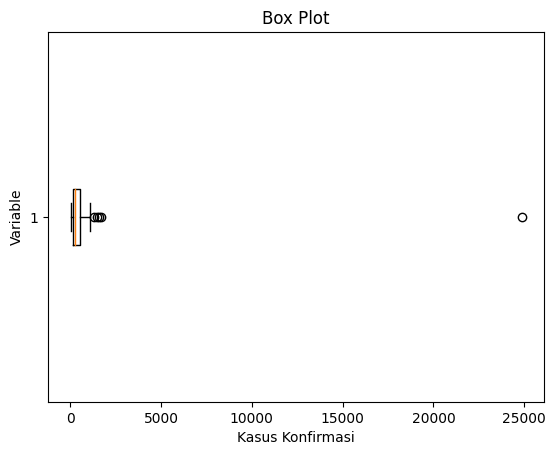

In [13]:
# menampilkan outlier dengan Box Plot

plt.boxplot(covid['KASUS KONFIRMASI'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Kasus Konfirmasi')
plt.title('Box Plot')

plt.show()

#### Normalisasi data

<Axes: >

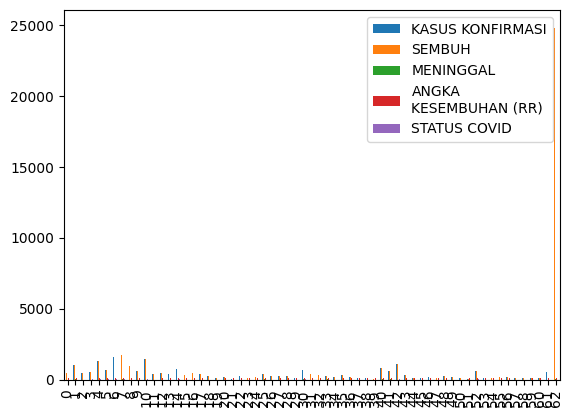

In [14]:
# menampilkan plot dataset

covid.plot(kind = 'bar')